<a href="https://colab.research.google.com/github/prabh2012/Data-Analytics-Laboratory/blob/main/Practical5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
uploaded = files.upload()

Saving images.jpg to images.jpg


In [ ]:
model = YOLO("yolov8n.pt")  # lightweight model


image 1/1 /content/images.jpg: 416x640 2 persons, 1 bicycle, 2 cars, 343.3ms
Speed: 18.1ms preprocess, 343.3ms inference, 60.5ms postprocess per image at shape (1, 3, 416, 640)
Class: bicycle
Confidence: 0.8472342491149902
Coordinates: [[119.0934066772461, 7.408165454864502, 231.0389862060547, 75.41922760009766]]
------
Class: person
Confidence: 0.7751368284225464
Coordinates: [[33.65098571777344, 78.3473892211914, 82.1700210571289, 174.85894775390625]]
------
Class: person
Confidence: 0.7726873755455017
Coordinates: [[245.9715118408203, 73.4705581665039, 275.0726623535156, 154.67149353027344]]
------
Class: car
Confidence: 0.6101710796356201
Coordinates: [[47.2957763671875, 81.65852355957031, 275.79266357421875, 175.49122619628906]]
------
Class: car
Confidence: 0.45145899057388306
Coordinates: [[1.4947649240493774, 111.40737915039062, 36.86422348022461, 154.61041259765625]]
------


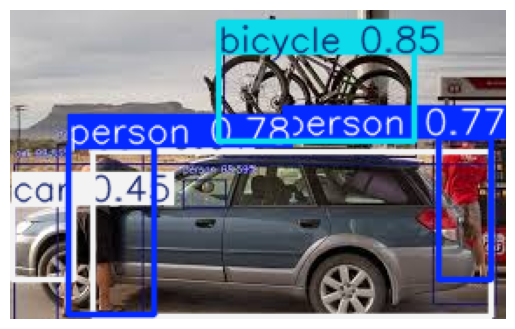

In [ ]:
# Get uploaded image name
image_path = list(uploaded.keys())[0]

# Run detection
results = model(image_path)
# Show detected image
for result in results:
    annotated_img = result.plot()

# Convert BGR to RGB
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.imshow(annotated_img)
plt.axis('off')
for r in results:
    for box in r.boxes:
        print("Class:", model.names[int(box.cls)])
        print("Confidence:", float(box.conf))
        print("Coordinates:", box.xyxy.tolist())
        print("------")